<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/euler-and-solve-ivp-BraydenMittag/blob/main/eulersolve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## pseudo code for solcing intial value/problems/ temporal evaluation of systens

1. **Import modules** import `math` for simple functions and constants; import `matplotlib.pyplot` for plotting
2. **Define the differential equation as a first-order system:** made a custom function from $\dot{\theta} + \omega_0^2 sin(\theta)=0$ to give $\dot{\theta} = \Omega$ an $\dot{\Omega} = - \omega_0^2 sin(\theta)$.
3. **assign variables and time span** define `omega_0` , the inital conditions (`theta_0` : initial angle; and `ang_vel_0`: initial angular velocity), and the time span
4. **solve differential equation numerically** call our custom euler solver
5. **plot results and test output**

In [25]:
import math
import matplotlib.pyplot as plt

In [26]:
theta_0 = 0
ang_vel_0 = 2

In [27]:
# import modules
import matplotlib.pyplot as plt
import math

In [28]:
# define system of equations
def euler_rigid_pendulum(omega_0, theta_0, ang_vel_0, t_0, t_f, n_steps):
  """
  This function calculates the solution to theta'' = - omega_0 ^2 sin(theta) with Euler's method.
  """
  dt = (t_f - t_0) / n_steps # calculate dt
  theta = [theta_0] # initialized theta list
  ang_vel = [ang_vel_0] # initialized angular velocity list
  t = [t_0] # initialized t list
  for _ in range(n_steps):
    theta_new = theta[-1] + ang_vel[-1] * dt # update x
    # ang_vel_new = ang_vel[-1] - omega_0 ** 2 * math.sin(theta[-1]) * dt # update angular velocity : using an explicit form
    ang_vel_new = ang_vel[-1] - omega_0 ** 2 * math.sin(theta_new) * dt
    t_new = t[-1] + dt # update t
    theta.append(theta_new) # append theta
    ang_vel.append(ang_vel_new) # append angular velocity
    t.append(t_new) # append t
  return t, theta, ang_vel

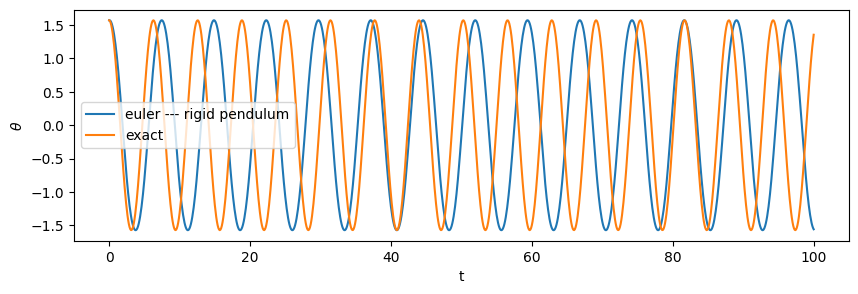

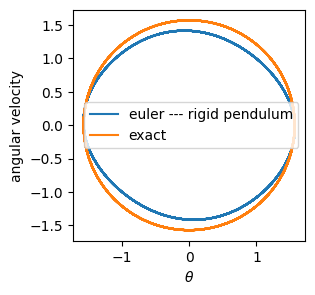

In [29]:
# assign variables, set initial conditions, and set time span
# assign variables and call function
theta_0 = math.pi / 2
omega_0 = 1
ang_vel_0     = 0
t_0     = 0
t_f     = 100
n_steps = 1000

t, theta, ang_vel = euler_rigid_pendulum(omega_0, theta_0, ang_vel_0, t_0, t_f, n_steps)

# get the exact values
theta_exact_rigid_pendulum = [theta_0 * math.cos(omega_0 * (t[i] - t_0)) + (ang_vel_0 / omega_0) * math.sin(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension
ang_vel_exact_rigid_pendulum = [- theta_0 * omega_0 * math.sin(omega_0 * (t[i] - t_0)) + ang_vel_0 * math.cos(omega_0 * (t[i] - t_0)) for i in range(len(t))] # using list comprehension

# plot with matplotlib
plt.figure(figsize=(10,3))
plt.plot(t, theta, label='euler --- rigid pendulum')
plt.plot(t, theta_exact_rigid_pendulum,label='exact')
plt.xlabel('t')
plt.ylabel('$\\theta$')
plt.legend()
plt.show()

# plot a phase portrait wiht matplotlib
plt.figure(figsize=(3,3))
plt.plot(theta, ang_vel, label='euler --- rigid pendulum')
plt.plot(theta_exact_rigid_pendulum, ang_vel_exact_rigid_pendulum,label='exact')
plt.xlabel('$\\theta$')
plt.ylabel('angular velocity')
plt.legend()
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp

# Problem parameters
omega0_sq = 1.0  # ω0^2 = 1
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Function defining the ODE system for solve_ivp
def pendulum_ode(t, y):
    theta, ang_vel = y
    dydt = [ang_vel, -omega0_sq * np.sin(theta)]
    return dydt

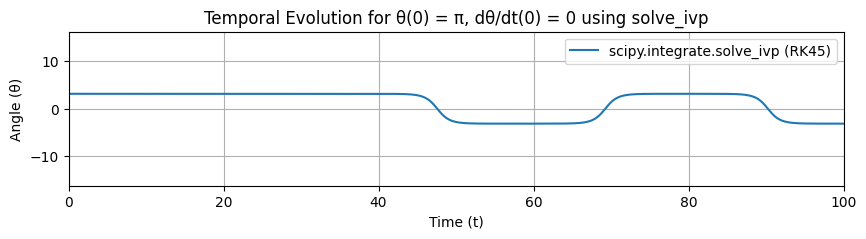

In [31]:
# Initial conditions
y0_1 = [math.pi, 0]

# Solve using solve_ivp
sol_1 = solve_ivp(pendulum_ode, t_span, y0_1, t_eval=t_eval, rtol=1e-8, atol=1e-8)

# Plotting the temporal evolution of θ
plt.figure(figsize=(10, 2))
plt.plot(sol_1.t, sol_1.y[0], label='scipy.integrate.solve_ivp (RK45)')
plt.xlim([0, 100])
plt.ylim([-5 * np.pi - 0.5, 5 * np.pi + 0.5])
plt.xlabel('Time (t)')
plt.ylabel('Angle (θ)')
plt.title(f'Temporal Evolution for θ(0) = π, dθ/dt(0) = 0 using solve_ivp')
plt.legend()
plt.grid(True)
plt.show()

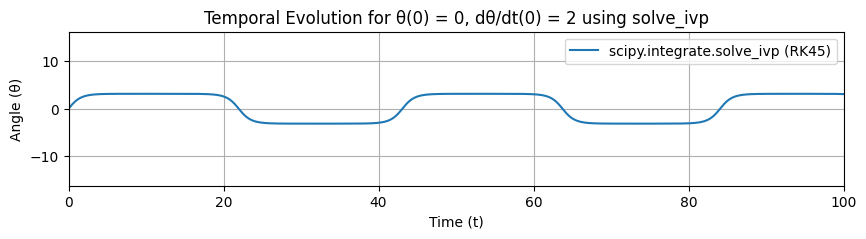

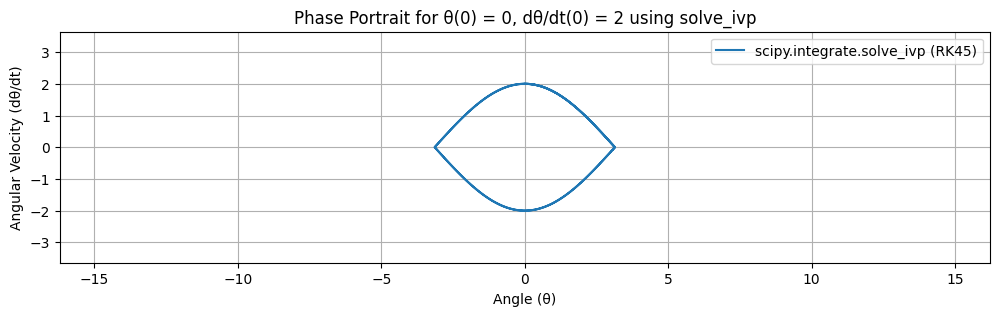

In [32]:
# Initial conditions
y0_2 = [0, 2]

# Solve using solve_ivp
sol_2 = solve_ivp(pendulum_ode, t_span, y0_2, t_eval=t_eval, rtol=1e-8, atol=1e-8)

# Plotting temporal evolution
plt.figure(figsize=(10, 2))
plt.plot(sol_2.t, sol_2.y[0], label='scipy.integrate.solve_ivp (RK45)')
plt.xlim([0, 100])
plt.ylim([-5 * np.pi - 0.5, 5 * np.pi + 0.5])
plt.xlabel('Time (t)')
plt.ylabel('Angle (θ)')
plt.title(f'Temporal Evolution for θ(0) = 0, dθ/dt(0) = 2 using solve_ivp')
plt.legend()
plt.grid(True)
plt.show()

# Plotting phase portrait
plt.figure(figsize=(12, 3))
plt.plot(sol_2.y[0], sol_2.y[1], label='scipy.integrate.solve_ivp (RK45)')
plt.xlim([-5 * np.pi - 0.5, 5 * np.pi + 0.5])
plt.ylim([-np.pi - 0.5, np.pi + 0.5])
plt.xlabel('Angle (θ)')
plt.ylabel('Angular Velocity (dθ/dt)')
plt.title(f'Phase Portrait for θ(0) = 0, dθ/dt(0) = 2 using solve_ivp')
plt.legend()
plt.grid(True)
plt.show()